In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
data_raw = pd.read_csv("D:\\ML&DL\\heart.csv")
data = data_raw.copy()

In [19]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [20]:
data.replace({"Age":0 , "RestingBP":0 , "Cholesterol":0 , "MaxHR":0 },np.nan , inplace=True)

In [21]:
data.isna().sum()

Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

In [22]:
data_categorical = data.select_dtypes("object")
data_numerical = data.select_dtypes(["float64" , "int64"]).iloc[:,:-1]
y = data.iloc[:,-1].values

In [23]:
from sklearn.preprocessing import LabelEncoder
label_enc = LabelEncoder()

In [24]:
data_categorical = data_categorical.apply(label_enc.fit_transform)

In [25]:
from sklearn.preprocessing import OneHotEncoder
ohe_enc = OneHotEncoder()

In [26]:
data_categorical_bin = data_categorical[["Sex","ExerciseAngina"]]

In [27]:
data_ohe = ohe_enc.fit_transform(data_categorical[["ChestPainType", "RestingECG" , "ST_Slope"]].values).toarray()

In [28]:
data_ohe.shape

(918, 10)

In [29]:
data = np.concatenate([data_numerical.values , data_categorical_bin.values , data_ohe], axis = 1)

In [30]:
pd.DataFrame(data)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,40.0,140.0,289.0,0.0,172.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49.0,160.0,180.0,0.0,156.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37.0,130.0,283.0,0.0,98.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,48.0,138.0,214.0,0.0,108.0,1.5,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,54.0,150.0,195.0,0.0,122.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45.0,110.0,264.0,0.0,132.0,1.2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
914,68.0,144.0,193.0,1.0,141.0,3.4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
915,57.0,130.0,131.0,0.0,115.0,1.2,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
916,57.0,130.0,236.0,0.0,174.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [31]:
from sklearn.impute import KNNImputer

In [32]:
imputer = KNNImputer(n_neighbors=3)

In [33]:
data = imputer.fit_transform(data)

In [34]:

from sklearn.preprocessing import MinMaxScaler

In [35]:
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [36]:
X = data

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.tree import plot_tree
from sklearn.model_selection import ShuffleSplit , GridSearchCV

In [38]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.3 , random_state=1234)

In [39]:
dtree = DecisionTreeClassifier(criterion='entropy' , max_depth=8 , max_leaf_nodes=12)
dtree.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,12
,min_impurity_decrease,0.0
,class_weight,None


In [40]:
dtree.score(X_train,y_train)

0.8644859813084113

In [41]:
dtree.score(X_test,y_test)

0.8695652173913043

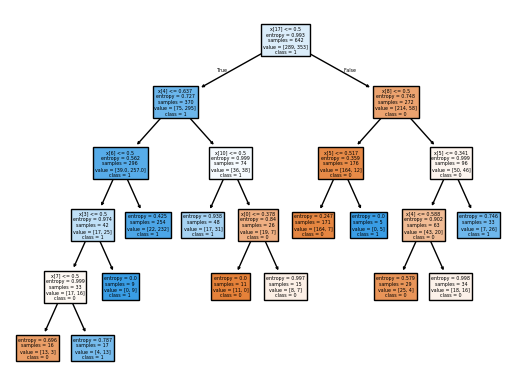

In [42]:
fig = plt.Figure(figsize=(45,30))
_ = plot_tree(dtree ,class_names=["0" , "1"] , filled=True)

In [43]:
dtree = DecisionTreeClassifier()
max_depth = np.arange(2,9,1)
max_leaf_nodes = [15,16,17,18,19,20,21,22,23,24,25]
min_sample_leaf = np.arange(4,30,4)
params = {
    "criterion" : ["entropy" , "gini"] ,
    'max_depth' : max_depth , 
    'max_leaf_nodes' : max_leaf_nodes,
    'min_samples_leaf' : min_sample_leaf,
}
cv= ShuffleSplit(n_splits=5 , test_size=0.3 , random_state=1234)
dtree_clf = GridSearchCV(dtree , scoring='accuracy' , cv=cv , param_grid=params , verbose=1, return_train_score=True)

In [44]:
dtree_clf.fit(X , y)

Fitting 5 folds for each of 1078 candidates, totalling 5390 fits


,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['entropy', 'gini'], 'max_depth': array([2, 3, 4, 5, 6, 7, 8]), 'max_leaf_nodes': [15, 16, ...], 'min_samples_leaf': array([ 4, 8..., 20, 24, 28])}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,ShuffleSplit(...ain_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


In [45]:
dtree_clf.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_criterion', 'param_max_depth', 'param_max_leaf_nodes', 'param_min_samples_leaf', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score', 'split0_train_score', 'split1_train_score', 'split2_train_score', 'split3_train_score', 'split4_train_score', 'mean_train_score', 'std_train_score'])

In [46]:
test_score = dtree_clf.cv_results_['mean_test_score']
train_score = dtree_clf.cv_results_['mean_train_score']

In [47]:
dtree_clf.score(X_train , y_train)

0.8598130841121495

In [48]:
dtree_clf.score(X_test , y_test)

0.9130434782608695

In [49]:
arg_max = test_score.argmax()

In [50]:
dtree_clf_params = dtree_clf.cv_results_['params']

In [51]:
dtree_clf_params[arg_max]

{'criterion': 'gini',
 'max_depth': 6,
 'max_leaf_nodes': 15,
 'min_samples_leaf': 12}

In [52]:
new_dtree = DecisionTreeClassifier(criterion='gini' , max_depth=7 , max_leaf_nodes= 15 , min_samples_leaf=12)
new_dtree.fit(X_train , y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,12
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,15
,min_impurity_decrease,0.0
,class_weight,None


In [53]:
new_dtree.score(X_train , y_train)

0.8535825545171339

In [54]:
new_dtree.score(X_test , y_test)

0.8768115942028986